# NB09 — Gold Layer (DuckDB) — Émulation Snowflake Dynamic Tables

**Source** : `silver.trays` (Iceberg, ADLS Gen2)
**Moteur** : DuckDB — syntaxe SQL portable vers Snowflake Dynamic Tables

**Tables Gold produites :**
 - `gold_series`    → grain plateau, pour les courbes timeline
 - `gold_day_stats` → grain journée, pour le tableau récap
 - `gold_heatmap`   → grain position 15×10, pour la heatmap cumulée

In [22]:
import sys
sys.path.insert(0, "..")
 
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick
from IPython.display import display
 
from src.config.settings import (
    SILVER_STORAGE_ACCOUNT_NAME,
    SILVER_STORAGE_ACCOUNT_KEY,
)
 
TARGET_DATE = "2026-05-15"
year, month, day = [int(x) for x in TARGET_DATE.split("-")]
 
SILVER_ROOT = "abfs://silver@dlsecatcandlingfrcedev.dfs.core.windows.net/trays_iceberg"
 
CAM_ZONES = {
    "cam_A": (7, 14, 0, 4),
    "cam_B": (0,  7, 0, 4),
    "cam_C": (7, 14, 5, 9),
    "cam_D": (0,  7, 5, 9),
}
CAM_COLORS = {
    "cam_A": "#E63946",
    "cam_B": "#457B9D",
    "cam_C": "#2A9D8F",
    "cam_D": "#F4A261",
}
CELL_COLORS = [
    "#E63946", "#F4A261", "#2A9D8F", "#457B9D", "#A8DADC",
    "#6A0572", "#F77F00", "#06A77D", "#D62246", "#4CC9F0",
]
ROLLING_WINDOW = 50

In [23]:
con = duckdb.connect()
 
con.execute("INSTALL iceberg; LOAD iceberg;")
con.execute("INSTALL azure;   LOAD azure;")
 
conn_str = (
    f"AccountName={SILVER_STORAGE_ACCOUNT_NAME};"
    f"AccountKey={SILVER_STORAGE_ACCOUNT_KEY};"
    f"DefaultEndpointsProtocol=https;"
    f"EndpointSuffix=core.windows.net"
)
con.execute(f"""
    CREATE SECRET azure_secret (
        TYPE AZURE,
        PROVIDER CONFIG,
        CONNECTION_STRING '{conn_str}'
    );
""")
 
con.execute("SET unsafe_enable_version_guessing = true;")
 
con.execute(f"""
    CREATE OR REPLACE VIEW silver_trays AS
    SELECT *
    FROM iceberg_scan('{SILVER_ROOT}');
""")
 
count = con.execute(
    f"SELECT COUNT(*) FROM silver_trays "
    f"WHERE year={year} AND month={month} AND day={day}"
).fetchone()[0]
print(f"✓ silver_trays accessible — {count} plateaux pour {TARGET_DATE}")

✓ silver_trays accessible — 1344 plateaux pour 2026-05-15


In [24]:
# %% [markdown]
# ## 2. gold_series — grain plateau (Python + DuckDB)
#
# Calcul Python pour les extractions positionnelles sur matrix_compact,
# puis enregistrement dans DuckDB pour les requêtes SQL suivantes.
#
# NOTE Snowflake : remplacer par REGEXP_COUNT(col_str, '3') / 15.0 * 100
 
# %%
df_base = con.execute(f"""
    SELECT
        ROW_NUMBER() OVER (ORDER BY candled_at) - 1 AS tray_index,
        tray_id, machine_id, candled_at, matrix_compact,
        n_fertile, n_clear, n_early_dead, n_late_dead, n_missing
    FROM silver_trays
    WHERE year={year} AND month={month} AND day={day}
    ORDER BY candled_at
""").df()

In [25]:
for j in range(10):
    df_base[f"clear_C{j+1:02d}"] = df_base["matrix_compact"].apply(
        lambda m, j=j: sum(1 for r in range(15) if m[r*10+j] == "3") / 15 * 100
    )
 
# Late dead (code '4') par caméra
for cam, (r0, r1, c0, c1) in CAM_ZONES.items():
    zone_size = (r1 - r0 + 1) * (c1 - c0 + 1)  # 40
    df_base[f"late_dead_{cam}"] = df_base["matrix_compact"].apply(
        lambda m, r0=r0, r1=r1, c0=c0, c1=c1: sum(
            1 for r in range(r0, r1+1)
            for c in range(c0, c1+1)
            if m[r*10+c] == "4"
        ) / zone_size * 100
    )
 
# Enregistrer dans DuckDB
con.register("gold_series", df_base)
 
print(f"✓ gold_series — {len(df_base)} lignes")
df_base.drop(columns="matrix_compact").head(3)

✓ gold_series — 1344 lignes


,tray_index,tray_id,machine_id,candled_at,n_fertile,n_clear,n_early_dead,n_late_dead,n_missing,clear_C01,...,clear_C05,clear_C06,clear_C07,clear_C08,clear_C09,clear_C10,late_dead_cam_A,late_dead_cam_B,late_dead_cam_C,late_dead_cam_D
0,0,8cf7f36e78f48eea8efb566d6630b86d63aa86876eae18...,PMAF-C012501,2026-05-15 06:32:48.638548+02:00,130,14,2,4,0,13.333333,...,6.666667,20.0,0.000000,13.333333,13.333333,6.666667,2.5,0.0,2.5,5.0
1,1,660c788752bfb12168806bb715c98c1c2f7b22533f9c83...,PMAF-C012501,2026-05-15 06:32:54.357327+02:00,136,12,0,2,0,13.333333,...,6.666667,20.0,0.000000,0.000000,0.000000,13.333333,2.5,0.0,2.5,0.0
2,2,53f2a420da86252697cdc9ff3772e4d3656955509e7b5c...,PMAF-C012501,2026-05-15 06:33:00.574953+02:00,141,7,1,1,0,0.000000,...,0.000000,0.0,6.666667,6.666667,6.666667,0.000000,0.0,0.0,2.5,0.0


In [26]:
# %% [markdown]
# ## 3. gold_day_stats — grain journée
 
# %%
con.execute(f"""
    CREATE OR REPLACE TABLE gold_day_stats AS
    SELECT
        machine_id,
        DATE '{TARGET_DATE}'                                       AS date,
        COUNT(*)                                                   AS total_plateaux,
        COUNT(*) * 150                                             AS total_oeufs,
        SUM(n_fertile)                                             AS n_fertile,
        SUM(n_clear)                                               AS n_clear,
        SUM(n_early_dead)                                          AS n_early_dead,
        SUM(n_late_dead)                                           AS n_late_dead,
        SUM(n_missing)                                             AS n_missing,
        ROUND(SUM(n_fertile)    / (COUNT(*) * 150.0) * 100, 2)    AS pct_fertile,
        ROUND(SUM(n_clear)      / (COUNT(*) * 150.0) * 100, 2)    AS pct_clear,
        ROUND(SUM(n_early_dead) / (COUNT(*) * 150.0) * 100, 2)    AS pct_early_dead,
        ROUND(SUM(n_late_dead)  / (COUNT(*) * 150.0) * 100, 2)    AS pct_late_dead,
        ROUND(SUM(n_missing)    / (COUNT(*) * 150.0) * 100, 2)    AS pct_missing,
        -- Late dead par caméra depuis gold_series
        ROUND(AVG(late_dead_cam_a), 3)                             AS avg_late_dead_cam_A,
        ROUND(AVG(late_dead_cam_b), 3)                             AS avg_late_dead_cam_B,
        ROUND(AVG(late_dead_cam_c), 3)                             AS avg_late_dead_cam_C,
        ROUND(AVG(late_dead_cam_d), 3)                             AS avg_late_dead_cam_D,
        -- Clairs par cellule depuis gold_series
        ROUND(AVG(clear_c01), 2) AS avg_clear_C01,
        ROUND(AVG(clear_c02), 2) AS avg_clear_C02,
        ROUND(AVG(clear_c03), 2) AS avg_clear_C03,
        ROUND(AVG(clear_c04), 2) AS avg_clear_C04,
        ROUND(AVG(clear_c05), 2) AS avg_clear_C05,
        ROUND(AVG(clear_c06), 2) AS avg_clear_C06,
        ROUND(AVG(clear_c07), 2) AS avg_clear_C07,
        ROUND(AVG(clear_c08), 2) AS avg_clear_C08,
        ROUND(AVG(clear_c09), 2) AS avg_clear_C09,
        ROUND(AVG(clear_c10), 2) AS avg_clear_C10,
        MIN(candled_at)                                            AS candling_start,
        MAX(candled_at)                                            AS candling_end,
        DATEDIFF('minute', MIN(candled_at), MAX(candled_at))       AS duration_min
    FROM gold_series
    GROUP BY machine_id;
""")


In [27]:
df_day = con.execute("SELECT * FROM gold_day_stats").df()
print("✓ gold_day_stats")
display(df_day.T.rename(columns={0: "Valeur"}))

✓ gold_day_stats


,Valeur
machine_id,PMAF-C012501
date,2026-05-15 00:00:00
total_plateaux,1344
total_oeufs,201600
n_fertile,178908.0
n_clear,17804.0
n_early_dead,1614.0
n_late_dead,3174.0
n_missing,100.0
pct_fertile,88.74


In [28]:
heatmap_rows = []
for r in range(15):
    for c in range(10):
        idx = r * 10 + c
        col_data = df_base["matrix_compact"].apply(lambda m, i=idx: m[i])
        n = len(col_data)
        heatmap_rows.append({
            "row":            r,
            "col":            c,
            "row_label":      f"L{r+1:02d}",
            "col_label":      f"C{c+1:02d}",
            "machine_id":     df_base["machine_id"].iloc[0],
            "date":           TARGET_DATE,
            "n_plateaux":     n,
            "fertile_rate":   round((col_data == "1").mean() * 100, 3),
            "clear_rate":     round((col_data == "3").mean() * 100, 3),
            "early_dead_rate":round((col_data == "2").mean() * 100, 3),
            "late_dead_rate": round((col_data == "4").mean() * 100, 3),
            "missing_rate":   round((col_data == "0").mean() * 100, 3),
        })
 
df_heatmap = pd.DataFrame(heatmap_rows)
con.register("gold_heatmap", df_heatmap)
 
print(f"✓ gold_heatmap — {len(df_heatmap)} positions")
df_heatmap.head(5)
 

✓ gold_heatmap — 150 positions


,row,col,row_label,col_label,machine_id,date,n_plateaux,fertile_rate,clear_rate,early_dead_rate,late_dead_rate,missing_rate
0,0,0,L01,C01,PMAF-C012501,2026-05-15,1344,89.881,9.301,0.670,0.149,0.0
1,0,1,L01,C02,PMAF-C012501,2026-05-15,1344,89.732,8.333,0.818,1.116,0.0
2,0,2,L01,C03,PMAF-C012501,2026-05-15,1344,89.881,8.333,0.372,1.414,0.0
3,0,3,L01,C04,PMAF-C012501,2026-05-15,1344,88.170,8.705,1.414,1.711,0.0
4,0,4,L01,C05,PMAF-C012501,2026-05-15,1344,87.946,9.747,1.042,1.265,0.0


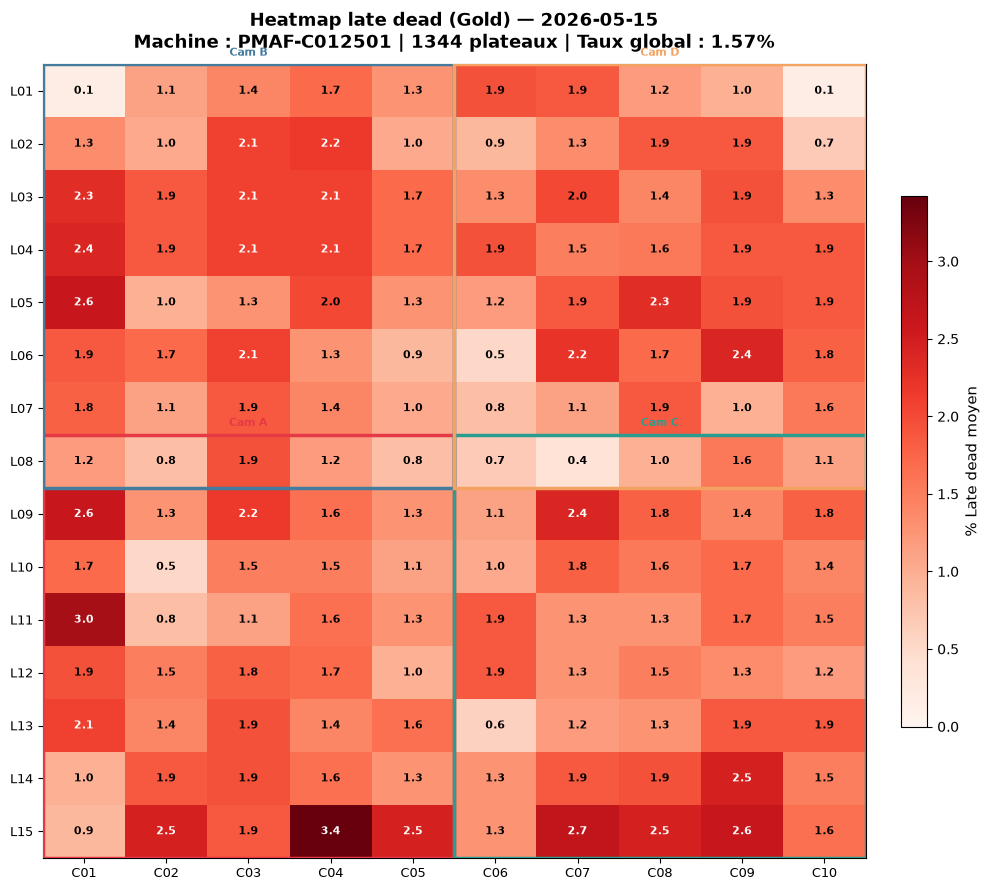

In [29]:
pivot_ld = df_heatmap.pivot(index="row", columns="col", values="late_dead_rate").values
 
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(pivot_ld, cmap="Reds", aspect="auto",
               norm=mcolors.Normalize(vmin=0, vmax=max(pivot_ld.max(), 0.01)))
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("% Late dead moyen", fontsize=11)
 
for r in range(15):
    for c in range(10):
        val = pivot_ld[r, c]
        tc = "white" if val > pivot_ld.max() * 0.6 else "black"
        ax.text(c, r, f"{val:.1f}", ha="center", va="center",
                fontsize=8, color=tc, fontweight="bold")
 
cam_rects = {
    "A": dict(r=(7, 14), c=(0, 4), color="#E63946"),
    "B": dict(r=(0,  7), c=(0, 4), color="#457B9D"),
    "C": dict(r=(7, 14), c=(5, 9), color="#2A9D8F"),
    "D": dict(r=(0,  7), c=(5, 9), color="#F4A261"),
}
for cam, zone in cam_rects.items():
    r0, r1 = zone["r"]
    c0, c1 = zone["c"]
    rect = plt.Rectangle((c0-0.5, r0-0.5), c1-c0+1, r1-r0+1,
                          linewidth=2.5, edgecolor=zone["color"],
                          facecolor="none", zorder=3)
    ax.add_patch(rect)
    ax.text(c0+(c1-c0)/2, r0-0.72, f"Cam {cam}",
            ha="center", va="center", fontsize=8,
            color=zone["color"], fontweight="bold")
 
ax.set_xticks(range(10))
ax.set_xticklabels([f"C{j+1:02d}" for j in range(10)], fontsize=9)
ax.set_yticks(range(15))
ax.set_yticklabels([f"L{r+1:02d}" for r in range(15)], fontsize=9)
ax.set_title(f"Heatmap late dead (Gold) — {TARGET_DATE}\n"
             f"Machine : {df_base['machine_id'].iloc[0]} | "
             f"{len(df_base)} plateaux | "
             f"Taux global : {pivot_ld.mean():.2f}%",
             fontsize=13, fontweight="bold", pad=12)
 
plt.tight_layout()
plt.show()

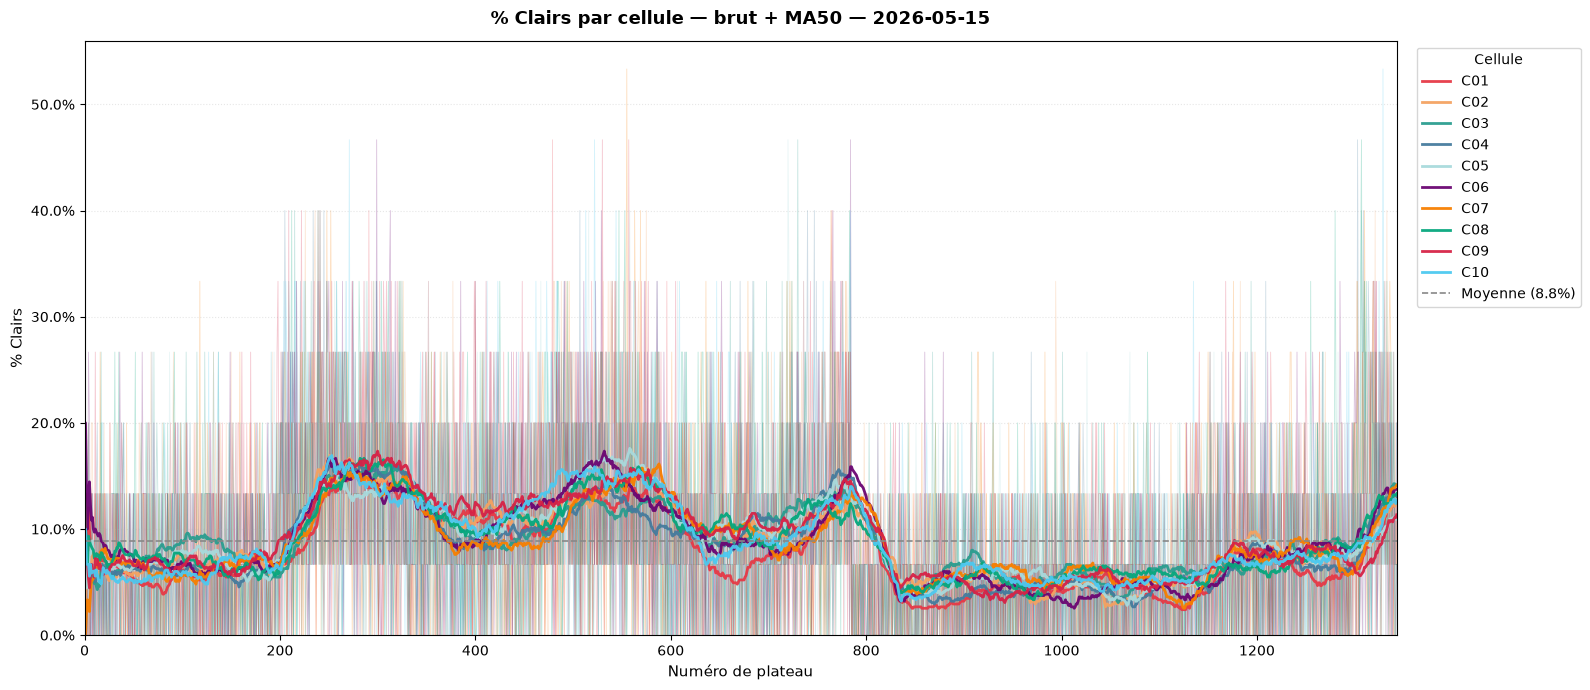

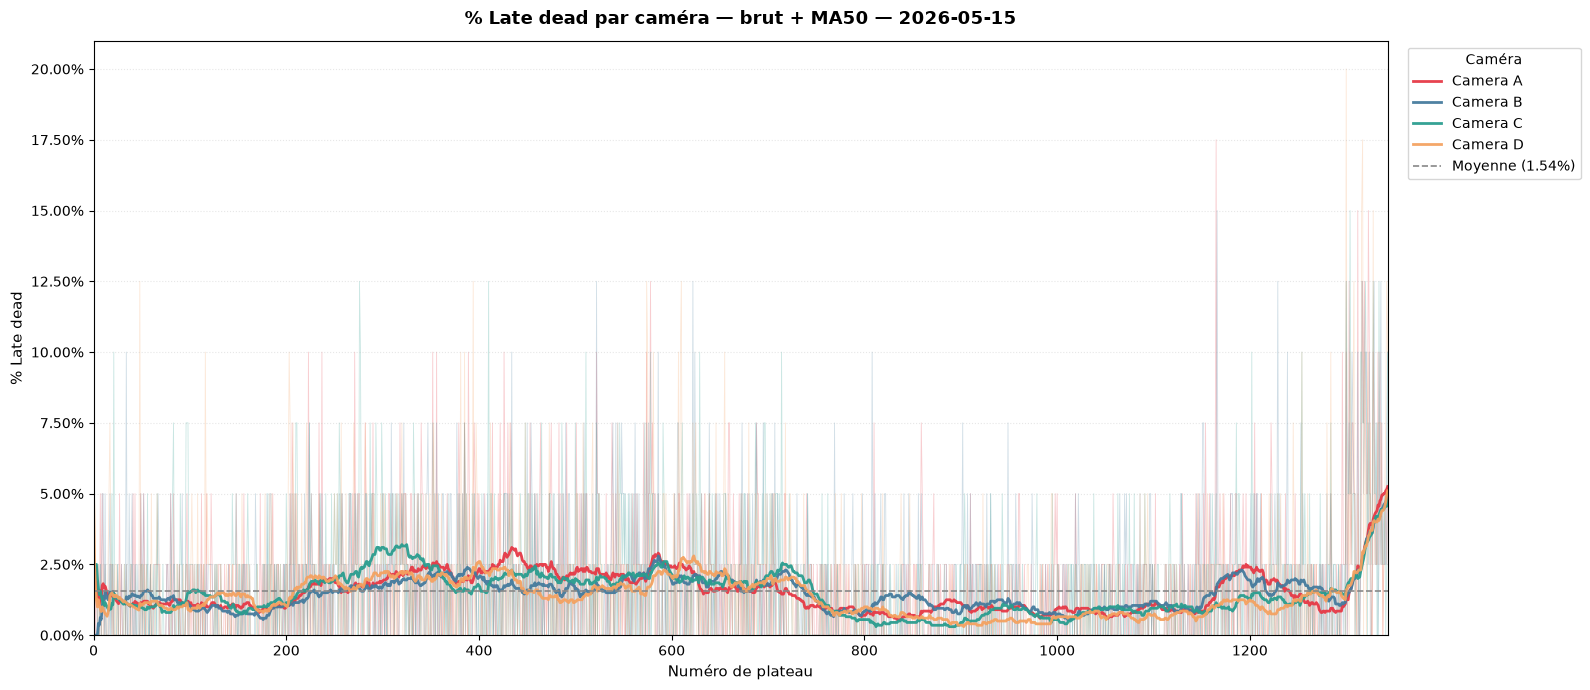

In [30]:
# %% [markdown]
# ## 6. Courbes timeline depuis gold_series
 
# %%
cell_cols = [f"clear_C{j+1:02d}" for j in range(10)]
cam_cols  = [f"late_dead_{c}" for c in ["cam_A", "cam_B", "cam_C", "cam_D"]]
 
# MA50
for col in cell_cols + cam_cols:
    df_base[f"{col}_ma"] = (
        df_base[col].rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    )
 
x = df_base["tray_index"]
 
# ── Graphique A : clairs par cellule MA50 ──
fig, ax = plt.subplots(figsize=(16, 7))
for j, col in enumerate(cell_cols):
    ax.plot(x, df_base[col], color=CELL_COLORS[j],
            linewidth=0.6, alpha=0.25, zorder=1)
    ax.plot(x, df_base[f"{col}_ma"], color=CELL_COLORS[j],
            linewidth=2.0, alpha=0.95, zorder=2, label=f"C{j+1:02d}")
 
global_mean = df_base[cell_cols].values.mean()
ax.axhline(global_mean, color="#888888", linewidth=1.2, linestyle="--",
           label=f"Moyenne ({global_mean:.1f}%)")
ax.set_title(f"% Clairs par cellule — brut + MA{ROLLING_WINDOW} — {TARGET_DATE}",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Numéro de plateau", fontsize=11)
ax.set_ylabel("% Clairs", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_xlim(0, len(df_base)-1)
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=10, title="Cellule")
plt.tight_layout()
plt.show()
 
# ── Graphique B : late dead par caméra MA50 ──
fig, ax = plt.subplots(figsize=(16, 7))
for cam, color in CAM_COLORS.items():
    col = f"late_dead_{cam}"
    ax.plot(x, df_base[col], color=color,
            linewidth=0.6, alpha=0.25, zorder=1)
    ax.plot(x, df_base[f"{col}_ma"], color=color,
            linewidth=2.0, alpha=0.95, zorder=2,
            label=cam.replace("cam_", "Camera "))
 
global_ld = df_base[cam_cols].values.mean()
ax.axhline(global_ld, color="#888888", linewidth=1.2, linestyle="--",
           label=f"Moyenne ({global_ld:.2f}%)")
ax.set_title(f"% Late dead par caméra — brut + MA{ROLLING_WINDOW} — {TARGET_DATE}",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Numéro de plateau", fontsize=11)
ax.set_ylabel("% Late dead", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax.set_xlim(0, len(df_base)-1)
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=10, title="Caméra")
plt.tight_layout()
plt.show()

In [34]:
## 7. Tableau récap depuis gold_day_stats

row = df_day.iloc[0]
 
df_global = pd.DataFrame([{
    "Plateaux":        int(row["total_plateaux"]),
    "Œufs total":      int(row["total_oeufs"]),
    "Fertiles":        f"{int(row['n_fertile'])}  ({row['pct_fertile']}%)",
    "Clairs":          f"{int(row['n_clear'])}  ({row['pct_clear']}%)",
    "Morts précoces":  f"{int(row['n_early_dead'])}  ({row['pct_early_dead']}%)",
    "Morts tardifs":   f"{int(row['n_late_dead'])}  ({row['pct_late_dead']}%)",
    "Manquants":       f"{int(row['n_missing'])}  ({row['pct_missing']}%)",
    "Début":           pd.Timestamp(row["candling_start"]).strftime("%H:%M:%S"),
    "Fin":             pd.Timestamp(row["candling_end"]).strftime("%H:%M:%S"),
    "Durée (min)":     int(row["duration_min"]),
}]).T.rename(columns={0: "Valeur"})
 
print("── Stats globales ──────────────────────────────")
display(df_global)
 
# Late dead par caméra
df_cam_recap = pd.DataFrame([
    {"Caméra": cam.replace("cam_", "Camera "),
     "Taux moy. late dead (%)": row[f"avg_late_dead_{cam}"]}
    for cam in ["cam_A", "cam_B", "cam_C", "cam_D"]
]).set_index("Caméra")
 
print("\n── Late dead par caméra ────────────────────────")
display(df_cam_recap)
 
# Clairs par cellule
df_cell_recap = pd.DataFrame([
    {"Cellule": f"C{j+1:02d}",
     "Taux moy. clairs (%)": row[f"avg_clear_C{j+1:02d}"]}
    for j in range(10)
]).set_index("Cellule")
 
mean_c = df_cell_recap["Taux moy. clairs (%)"].mean()
df_cell_recap["vs moyenne"] = (df_cell_recap["Taux moy. clairs (%)"] - mean_c).apply(
    lambda v: f"+{v:.2f}pp" if v >= 0 else f"{v:.2f}pp"
)
 
print(f"\n── Clairs par cellule (moyenne = {mean_c:.2f}%) ──")
display(df_cell_recap)

── Stats globales ──────────────────────────────


,Valeur
Plateaux,1344
Œufs total,201600
Fertiles,178908 (88.74%)
Clairs,17804 (8.83%)
Morts précoces,1614 (0.8%)
Morts tardifs,3174 (1.57%)
Manquants,100 (0.05%)
Début,06:32:48
Fin,09:57:28
Durée (min),205



── Late dead par caméra ────────────────────────


,Taux moy. late dead (%)
Caméra,
Camera A,1.603
Camera B,1.564
Camera C,1.546
Camera D,1.456



── Clairs par cellule (moyenne = 8.83%) ──


,Taux moy. clairs (%),vs moyenne
Cellule,,
C01,8.00,-0.83pp
C02,8.95,+0.12pp
C03,9.05,+0.22pp
C04,8.47,-0.36pp
C05,9.08,+0.25pp
C06,8.83,-0.00pp
C07,8.73,-0.10pp
C08,9.03,+0.20pp
C09,9.23,+0.40pp


In [35]:
con.execute("""
    SELECT flock, flock_name, trolley, trolley_name, COUNT(*) as n
    FROM silver_trays
    WHERE year=2026 AND month=5 AND day=15
    GROUP BY 1,2,3,4
    LIMIT 10
""").df()

,flock,flock_name,trolley,trolley_name,n
0,32,4c6dc3a36e9d9ae1a25,30322022,30322022,36
1,5,30d72c3d43b3dfe31cf,30314025,30314025,29
2,37,b82a3411f02de1dfc9f,30309217,30309217,32
3,21,3ed06fe60d346c54fa3,20712122,20712122,32
4,11,b2123cf535cc4e44dd8,20702121,20702121,32
5,2,4a8e7fbd4447cec5aa2,20714024,20714024,32
6,34,4c6dc3a36e9d9ae1a25,30313000,30313000,29
7,25,080c997380324185ec8,30308023,30308023,34
8,3,6515c3f905d69ee2171,20715024,20715024,32
9,24,5878c6c4d74e9e7743e,30306000,30306000,32


In [36]:
# %% [markdown]
# ## 4b. gold_flock_stats — grain lot (flock)

# %%
df_flock = con.execute(f"""
    SELECT
        machine_id,
        DATE '{TARGET_DATE}'                                        AS date,
        flock_name,
        COUNT(DISTINCT flock)                                       AS n_flock_numbers,
        COUNT(DISTINCT trolley)                                     AS n_trolleys,
        COUNT(*)                                                    AS n_plateaux,
        COUNT(*) * 150                                              AS total_oeufs,
        SUM(n_fertile)                                              AS n_fertile,
        SUM(n_clear)                                                AS n_clear,
        SUM(n_early_dead)                                           AS n_early_dead,
        SUM(n_late_dead)                                            AS n_late_dead,
        SUM(n_missing)                                              AS n_missing,
        ROUND(SUM(n_fertile)    / (COUNT(*) * 150.0) * 100, 2)     AS pct_fertile,
        ROUND(SUM(n_clear)      / (COUNT(*) * 150.0) * 100, 2)     AS pct_clear,
        ROUND(SUM(n_early_dead) / (COUNT(*) * 150.0) * 100, 2)     AS pct_early_dead,
        ROUND(SUM(n_late_dead)  / (COUNT(*) * 150.0) * 100, 2)     AS pct_late_dead,
        ROUND(SUM(n_missing)    / (COUNT(*) * 150.0) * 100, 2)     AS pct_missing,
        MIN(candled_at)                                             AS candling_start,
        MAX(candled_at)                                             AS candling_end,
        DATEDIFF('minute', MIN(candled_at), MAX(candled_at))        AS duration_min
    FROM silver_trays
    WHERE year={year} AND month={month} AND day={day}
    GROUP BY machine_id, flock_name
    ORDER BY candling_start
""").df()

con.register("gold_flock_stats", df_flock)
print(f"✓ gold_flock_stats — {len(df_flock)} flocks")
display(df_flock)

# %% [markdown]
# ## 4c. gold_trolley_stats — grain chariot (trolley)

# %%
df_trolley = con.execute(f"""
    SELECT
        machine_id,
        DATE '{TARGET_DATE}'                                        AS date,
        trolley,
        trolley_name,
        flock_name,
        COUNT(*)                                                    AS n_plateaux,
        COUNT(*) * 150                                              AS total_oeufs,
        SUM(n_fertile)                                              AS n_fertile,
        SUM(n_clear)                                                AS n_clear,
        SUM(n_early_dead)                                           AS n_early_dead,
        SUM(n_late_dead)                                            AS n_late_dead,
        SUM(n_missing)                                              AS n_missing,
        ROUND(SUM(n_fertile)    / (COUNT(*) * 150.0) * 100, 2)     AS pct_fertile,
        ROUND(SUM(n_clear)      / (COUNT(*) * 150.0) * 100, 2)     AS pct_clear,
        ROUND(SUM(n_early_dead) / (COUNT(*) * 150.0) * 100, 2)     AS pct_early_dead,
        ROUND(SUM(n_late_dead)  / (COUNT(*) * 150.0) * 100, 2)     AS pct_late_dead,
        ROUND(SUM(n_missing)    / (COUNT(*) * 150.0) * 100, 2)     AS pct_missing,
        MIN(tray_seq)                                               AS first_tray_seq,
        MAX(tray_seq)                                               AS last_tray_seq,
        MIN(candled_at)                                             AS candling_start,
        MAX(candled_at)                                             AS candling_end,
        DATEDIFF('minute', MIN(candled_at), MAX(candled_at))        AS duration_min
    FROM silver_trays
    WHERE year={year} AND month={month} AND day={day}
    GROUP BY machine_id, trolley, trolley_name, flock_name
    ORDER BY candling_start
""").df()

con.register("gold_trolley_stats", df_trolley)
print(f"✓ gold_trolley_stats — {len(df_trolley)} trolleys")
display(df_trolley)

✓ gold_flock_stats — 15 flocks


,machine_id,date,flock_name,n_flock_numbers,n_trolleys,n_plateaux,total_oeufs,n_fertile,n_clear,n_early_dead,n_late_dead,n_missing,pct_fertile,pct_clear,pct_early_dead,pct_late_dead,pct_missing,candling_start,candling_end,duration_min
0,PMAF-C012501,2026-05-15,43e6ab99aeea0b2d6ca,1,1,32,4800,4402.0,311.0,29.0,58.0,0.0,91.71,6.48,0.60,1.21,0.00,2026-05-15 06:32:48.638548+02:00,2026-05-15 06:36:39.747686+02:00,4
1,PMAF-C012501,2026-05-15,4a8e7fbd4447cec5aa2,1,1,32,4800,4403.0,307.0,34.0,56.0,0.0,91.73,6.40,0.71,1.17,0.00,2026-05-15 06:37:05.048266+02:00,2026-05-15 06:40:17.309835+02:00,3
2,PMAF-C012501,2026-05-15,6515c3f905d69ee2171,1,1,32,4800,4375.0,334.0,40.0,51.0,0.0,91.15,6.96,0.83,1.06,0.00,2026-05-15 06:40:29.218608+02:00,2026-05-15 06:43:52.342567+02:00,3
3,PMAF-C012501,2026-05-15,384e0b15ac732c66cad,1,1,32,4800,4392.0,299.0,41.0,68.0,0.0,91.50,6.23,0.85,1.42,0.00,2026-05-15 06:44:04.296971+02:00,2026-05-15 06:47:16.452742+02:00,3
4,PMAF-C012501,2026-05-15,30d72c3d43b3dfe31cf,2,2,72,10800,9899.0,719.0,75.0,107.0,0.0,91.66,6.66,0.69,0.99,0.00,2026-05-15 06:47:28.396032+02:00,2026-05-15 06:59:24.996814+02:00,12
5,PMAF-C012501,2026-05-15,4e3badeb811fb71f830,4,4,129,19350,15908.0,2852.0,168.0,422.0,0.0,82.21,14.74,0.87,2.18,0.00,2026-05-15 06:59:36.904407+02:00,2026-05-15 07:14:14.974399+02:00,15
6,PMAF-C012501,2026-05-15,b2123cf535cc4e44dd8,4,4,128,19200,16675.0,1951.0,170.0,404.0,0.0,86.85,10.16,0.89,2.10,0.00,2026-05-15 07:14:27.887528+02:00,2026-05-15 07:32:32.027689+02:00,18
7,PMAF-C012501,2026-05-15,ddf88a452eda0459486,2,2,65,9750,8170.0,1320.0,92.0,168.0,0.0,83.79,13.54,0.94,1.72,0.00,2026-05-15 07:32:43.910388+02:00,2026-05-15 07:41:10.508660+02:00,9
8,PMAF-C012501,2026-05-15,0484890e910a9135471,2,2,68,10200,8459.0,1394.0,112.0,235.0,0.0,82.93,13.67,1.10,2.30,0.00,2026-05-15 07:41:22.468649+02:00,2026-05-15 07:53:59.811463+02:00,12
9,PMAF-C012501,2026-05-15,3ed06fe60d346c54fa3,4,4,128,19200,16964.0,1729.0,138.0,369.0,0.0,88.35,9.01,0.72,1.92,0.00,2026-05-15 07:54:11.738479+02:00,2026-05-15 08:10:04.312176+02:00,16


✓ gold_trolley_stats — 41 trolleys


,machine_id,date,trolley,trolley_name,flock_name,n_plateaux,total_oeufs,n_fertile,n_clear,n_early_dead,...,pct_fertile,pct_clear,pct_early_dead,pct_late_dead,pct_missing,first_tray_seq,last_tray_seq,candling_start,candling_end,duration_min
0,PMAF-C012501,2026-05-15,20713024,20713024,43e6ab99aeea0b2d6ca,32,4800,4402.0,311.0,29.0,...,91.71,6.48,0.60,1.21,0.00,1,32,2026-05-15 06:32:48.638548+02:00,2026-05-15 06:36:39.747686+02:00,4
1,PMAF-C012501,2026-05-15,20714024,20714024,4a8e7fbd4447cec5aa2,32,4800,4403.0,307.0,34.0,...,91.73,6.40,0.71,1.17,0.00,33,64,2026-05-15 06:37:05.048266+02:00,2026-05-15 06:40:17.309835+02:00,3
2,PMAF-C012501,2026-05-15,20715024,20715024,6515c3f905d69ee2171,32,4800,4375.0,334.0,40.0,...,91.15,6.96,0.83,1.06,0.00,65,96,2026-05-15 06:40:29.218608+02:00,2026-05-15 06:43:52.342567+02:00,3
3,PMAF-C012501,2026-05-15,20716024,20716024,384e0b15ac732c66cad,32,4800,4392.0,299.0,41.0,...,91.50,6.23,0.85,1.42,0.00,97,128,2026-05-15 06:44:04.296971+02:00,2026-05-15 06:47:16.452742+02:00,3
4,PMAF-C012501,2026-05-15,30314025,30314025,30d72c3d43b3dfe31cf,29,4350,3996.0,284.0,27.0,...,91.86,6.53,0.62,0.99,0.00,129,157,2026-05-15 06:47:28.396032+02:00,2026-05-15 06:51:03.897062+02:00,4
5,PMAF-C012501,2026-05-15,30315024,30315024,30d72c3d43b3dfe31cf,43,6450,5903.0,435.0,48.0,...,91.52,6.74,0.74,0.99,0.00,158,200,2026-05-15 06:51:15.804177+02:00,2026-05-15 06:59:24.996814+02:00,8
6,PMAF-C012501,2026-05-15,20706120,20706120,4e3badeb811fb71f830,32,4800,3974.0,679.0,38.0,...,82.79,14.15,0.79,2.27,0.00,201,232,2026-05-15 06:59:36.904407+02:00,2026-05-15 07:03:05.508833+02:00,4
7,PMAF-C012501,2026-05-15,20705121,20705121,4e3badeb811fb71f830,33,4950,4043.0,775.0,54.0,...,81.68,15.66,1.09,1.58,0.00,233,265,2026-05-15 07:03:17.430084+02:00,2026-05-15 07:06:41.009663+02:00,3
8,PMAF-C012501,2026-05-15,20708120,20708120,4e3badeb811fb71f830,32,4800,3923.0,708.0,47.0,...,81.73,14.75,0.98,2.54,0.00,266,297,2026-05-15 07:06:53.470362+02:00,2026-05-15 07:10:51.352983+02:00,4
9,PMAF-C012501,2026-05-15,20707021,20707021,4e3badeb811fb71f830,32,4800,3968.0,690.0,29.0,...,82.67,14.37,0.60,2.35,0.00,298,329,2026-05-15 07:11:03.293066+02:00,2026-05-15 07:14:14.974399+02:00,3
